In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt
import igraph as ig
os.chdir("C:/Users/ferra/desktop/TFM/clustering/spectral graph clustering/implementation")

In [24]:

with open("sc2017.dat", "r") as f:
    n = int(f.readline().strip())  
    
    edges = []
    for line in f:
        parts = line.strip().split()
        if len(parts) == 3:
            edges.append((int(parts[0]), int(parts[1]), float(parts[2])))


W = np.zeros((n, n))

for frm, to, weight in edges:
    W[frm, to] = weight  


print(W)
print(W.shape)

[[0.         0.15271    0.00088711 ... 0.00031683 0.0639356  0.0976143 ]
 [0.109643   0.         0.0383067  ... 0.0178112  0.229499   0.0189259 ]
 [0.00194485 0.116969   0.         ... 0.169341   0.0793915  0.00145864]
 ...
 [0.00081493 0.063809   0.19868    ... 0.         0.223128   0.00171135]
 [0.031221   0.156089   0.0176836  ... 0.0423603  0.         0.15824   ]
 [0.0761869  0.0205737  0.00051929 ... 0.00051929 0.252918   0.        ]]
(90, 90)


In [25]:
def laplacian_rw_spectrum(W,plot=False):
    n = W.shape[0]

    d = W.sum(axis=1)
    d_safe = np.where(d != 0, d, 1)
    D_inv = np.diag(1 / d_safe)

    L_rw = np.eye(n) - D_inv @ W
    
    evals, evecs = np.linalg.eig(L_rw)
    idx = np.argsort(evals)
    evals_ordered = evals[idx]
    evecs_ordered = evecs[:, idx]
    
    if plot:
        plt.figure(figsize=(8,5))
        plt.plot(range(1, n+1), evals_ordered, marker='o')
        plt.xlabel('i')
        plt.ylabel('Eigenvalue')
        plt.title('Random Walk Laplacian Spectrum')
        plt.grid(True)
        plt.show()
    
    return evals_ordered, evecs_ordered

In [26]:

from matplotlib.pyplot import plot


def laplacian_unnormalized_spectrum(W, plot=False):
    n = W.shape[0]
    d = W.sum(axis=1)
    D = np.diag(d)
    L = D - W
    evals, evecs = np.linalg.eig(L)
    idx = np.argsort(evals)
    evals_ordered = evals[idx]
    evecs_ordered = evecs[:, idx]
    
    if plot:
        plt.figure(figsize=(8,5))
        plt.plot(range(1, n+1), evals_ordered, marker='o')
        plt.xlabel('i')
        plt.ylabel('Eigenvalue')
        plt.title('Unnormalized Laplacian Spectrum')
        plt.grid(True)
        plt.show()
    
    return evals_ordered, evecs_ordered

In [27]:
laplacian_rw_spectrum(W)
laplacian_unnormalized_spectrum(W)

(array([-8.88178420e-16,  7.49722520e-01,  1.08969001e+00,  1.30302843e+00,
         1.59837157e+00,  1.62965710e+00,  1.82858536e+00,  1.93589145e+00,
         2.04386126e+00,  2.08040070e+00,  2.15509607e+00,  2.26407280e+00,
         2.28781449e+00,  2.33848220e+00,  2.44791438e+00,  2.47352420e+00,
         2.53106176e+00,  2.55542745e+00,  2.59957901e+00,  2.63464524e+00,
         2.65852728e+00,  2.68096563e+00,  2.72733009e+00,  2.76943867e+00,
         2.78104625e+00,  2.83994497e+00,  2.88208668e+00,  2.93471199e+00,
         2.94223823e+00,  2.96265333e+00,  2.98356594e+00,  2.99328992e+00,
         3.01946484e+00,  3.05117008e+00,  3.07135374e+00,  3.09516085e+00,
         3.17444685e+00,  3.18031588e+00,  3.19359111e+00,  3.22974754e+00,
         3.24175409e+00,  3.27446392e+00,  3.28802689e+00,  3.30104153e+00,
         3.31168891e+00,  3.36432246e+00,  3.40193291e+00,  3.40764931e+00,
         3.44255292e+00,  3.45831714e+00,  3.47098040e+00,  3.49788346e+00,
         3.5

This phenomenon is common: see Betzel et al., 2013 and Yeo et al., 2011.

Dense connectomes do not have a clear first-K eigenvalue gap.

In [43]:
def spectral_clustering(W, k, compute_calinski=True, compute_silhouette=True, compute_modularity=True, plot=False):
    n = W.shape[0]
    evals, evecs = laplacian_rw_spectrum(W,plot)
    X = evecs[:, :k].real
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=None)
    labels = kmeans.fit_predict(X)
    indicators = {}
    if compute_calinski:
        indicators['calinski_harabasz'] = calinski_harabasz_score(X, labels)
    if compute_silhouette:
        indicators['silhouette'] = silhouette_score(X, labels)
    if compute_modularity:
        g = ig.Graph.Weighted_Adjacency(W.tolist(), mode=ig.ADJ_DIRECTED)
        indicators['modularity'] = g.modularity(labels, weights=g.es["weight"])
    W_clusters = np.zeros((k, k))
    for i in range(k):
        for j in range(k):
            nodes_i = np.where(labels == i)[0]
            nodes_j = np.where(labels == j)[0]
            if len(nodes_i) > 0 and len(nodes_j) > 0:
                W_clusters[i, j] = W[np.ix_(nodes_i, nodes_j)].mean()
    return labels, W_clusters, indicators

In [44]:
from itertools import combinations
from sklearn.metrics import adjusted_rand_score

def spectral_clustering_ari(W, k, n_init=10):
    
    labels_list = []

    for _ in range(n_init):
        labels, _, _ = spectral_clustering(
            W, k=k,
            compute_calinski=False,
            compute_silhouette=False,
            compute_modularity=False
        )
        labels_list.append(labels)

    #Compute ARI:
    ari_values = [adjusted_rand_score(l1, l2) for l1, l2 in combinations(labels_list, 2)]
    ari_mean = np.mean(ari_values)

    return ari_mean

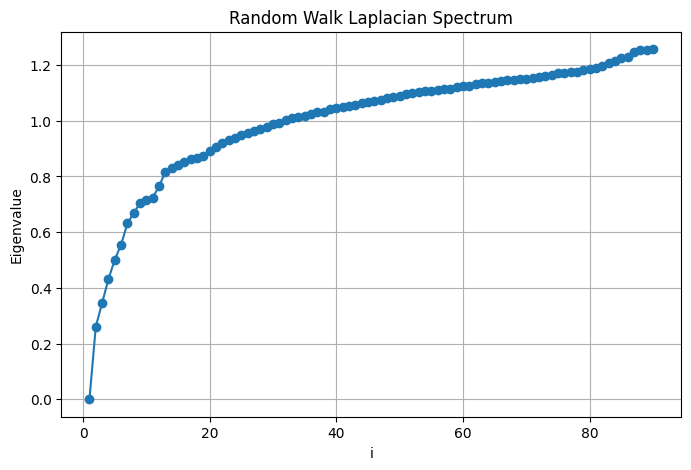

(array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0], dtype=int32),
 array([[0.06671532, 0.0209358 , 0.01687994],
        [0.02006037, 0.10173253, 0.01743678],
        [0.01585544, 0.01971525, 0.06777338]]),
 {'calinski_harabasz': 91.81348850667099,
  'silhouette': 0.4352105960819086,
  'modularity': 0.3436381869908537})

In [45]:
spectral_clustering(W, k=3,plot=True)

In [46]:

def spectral_clustering_indicators_vs_k(W, kmax):

    k_values = range(2, kmax + 1)
    calinski_list = []
    silhouette_list = []
    modularity_list = []
    ARI_list = []

    for k in k_values:
        labels, W_clusters, indicators = spectral_clustering(
            W, k=k,
            compute_calinski=True,
            compute_silhouette=True,
            compute_modularity=True
        )
        calinski_list.append(indicators.get('calinski_harabasz', np.nan))
        silhouette_list.append(indicators.get('silhouette', np.nan))
        modularity_list.append(indicators.get('modularity', np.nan))
        ARI_list.append(spectral_clustering_ari(W, k))

    plt.figure(figsize=(12, 4))

    plt.subplot(2, 2, 1)
    plt.plot(k_values, calinski_list, marker='o')
    plt.xlabel('k')
    plt.ylabel('Calinski-Harabasz')
    plt.title('Calinski-Harabasz vs k')
    plt.grid(True)

    plt.subplot(2, 2, 2)
    plt.plot(k_values, ARI_list, marker='o', color='purple')
    plt.xlabel('k')
    plt.ylabel('Adjusted Rand Index')
    plt.title('Adjusted Rand Index vs k')
    plt.grid(True)

    plt.subplot(2, 2, 3)
    plt.plot(k_values, silhouette_list, marker='o', color='orange')
    plt.xlabel('k')
    plt.ylabel('Silhouette')
    plt.title('Silhouette vs k')
    plt.grid(True)

    plt.subplot(2, 2, 4)
    plt.plot(k_values, modularity_list, marker='o', color='green')
    plt.xlabel('k')
    plt.ylabel('Modularity Q')
    plt.title('Modularity vs k')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    results = {
        'k_values': list(k_values),
        'calinski_harabasz': calinski_list,
        'silhouette': silhouette_list,
        'modularity': modularity_list,
        'adjusted_rand_index': ARI_list
    }

    return results

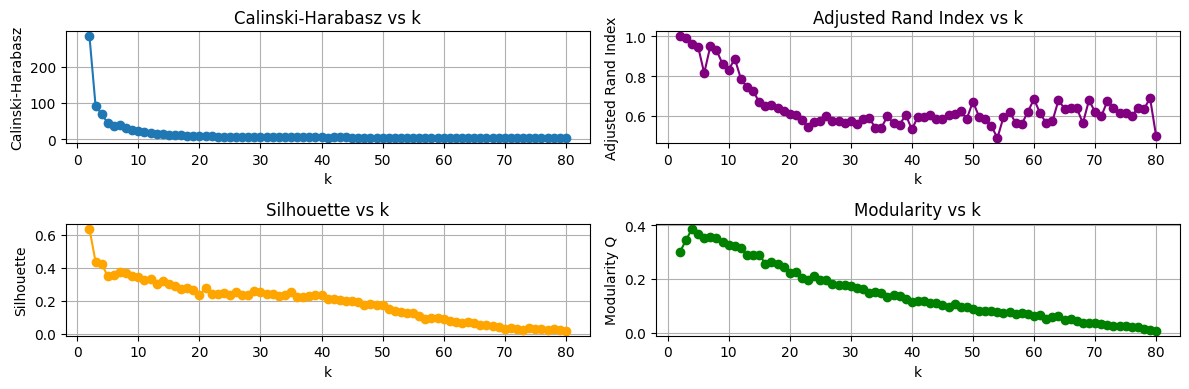

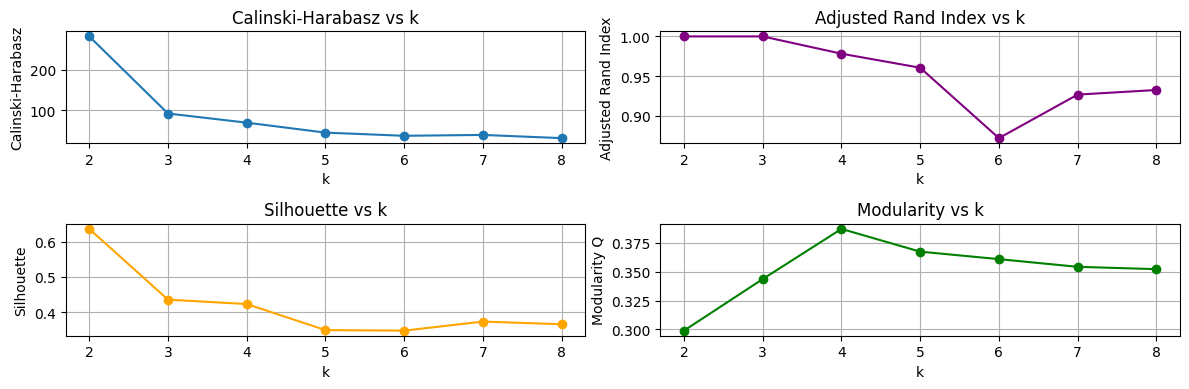

{'k_values': [2, 3, 4, 5, 6, 7, 8],
 'calinski_harabasz': [282.84965105798364,
  91.81348850667099,
  69.15565596602629,
  44.473041220970316,
  36.6178027242641,
  38.76511375178995,
  30.81150310509222],
 'silhouette': [0.6357810928296678,
  0.4352105960819086,
  0.4227725107034311,
  0.34882416888547724,
  0.34733374765191993,
  0.3730145326649828,
  0.3654521762977114],
 'modularity': [0.29887607960948054,
  0.34363818699085374,
  0.3871942965943658,
  0.3674511355463314,
  0.3609628520531505,
  0.3542819157723836,
  0.35226469249959524],
 'adjusted_rand_index': [np.float64(1.0),
  np.float64(1.0),
  np.float64(0.9782789748408296),
  np.float64(0.9606052555288139),
  np.float64(0.8720266651818843),
  np.float64(0.9268070379387656),
  np.float64(0.9325988774883784)]}

In [47]:
spectral_clustering_indicators_vs_k(W, kmax=80)
spectral_clustering_indicators_vs_k(W, kmax=8)

Note: Expected range for structural connectomes (Q ≈ 0.3–0.5)